Redes Neuronales y Graficos

In [14]:
from sklearn.datasets import make_gaussian_quantiles
#El propósito de esta función es crear un conjunto de datos que sea útil para probar y evaluar el rendimiento de algoritmos de clasificación.
import matplotlib.pyplot as plt
import numpy as np

Crear un set de datos

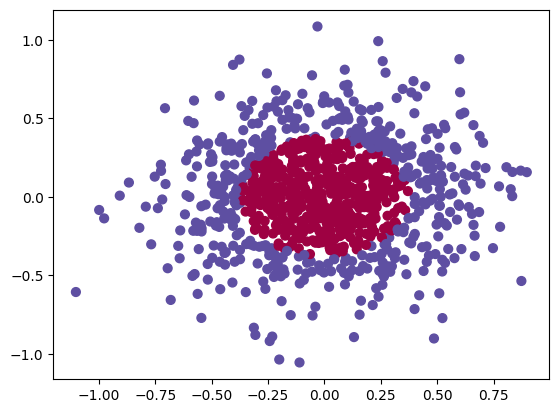

In [40]:
N = 1000
#Esta es la función principal que crea los datos.
gaussian_quantiles = make_gaussian_quantiles(mean=None #Los centros de las clases se eligen aleatoriamente
                                             ,cov=0.1 #Controla la varianza o dispersión de los puntos
                                             ,n_samples=N #Establece que el número total de puntos de datos a generar
                                             ,n_features=2 #Esto nos permite visualizar los datos en un plano 2D.
                                             ,n_classes=2 #Crea dos clases o grupos de datos.
                                             ,shuffle=True #Mezcla aleatoriamente las muestras después de generarlas
                                             ,random_state=None) #garantiza que la generación de los datos sea la misma cada vez que se ejecuta el código.
#Esta línea desempaqueta los datos generados por make_gaussian_quantiles. La función devuelve una tupla de dos elementos
X, Y = gaussian_quantiles
Y = Y[:,np.newaxis]
plt.scatter(X[:,0], X[:,1] #Dibuja los puntos
            , c=Y[:,0] #Asigna el color de cada punto según su etiqueta de clase
            , s=40 #Define el tamaño de cada punto en el gráfico.
            , cmap=plt.cm.Spectral); #Elige un mapa de colores específico

Función de inicialización de parámetros

El código que proporcionaste es una función de Python para inicializar los parámetros (pesos y sesgos) de una red neuronal profunda.

In [2]:
def initialize_parameters_deep(layer_dims): 
    #Este argumento es una lista que especifica la cantidad de neuronas en cada capa de la red. 
    #np.random.seed(1)
    parameters = {}
    #Se crea un diccionario vacío llamado
    L = len(layer_dims)
    #Se calcula el número total de capas en la red, incluyendo la capa de entrada. Este valor se guarda en la variable L.
    for l in range(0, L-1):
    #El bucle se ejecuta L-1 veces, ya que inicializamos los parámetros para las conexiones entre capas, no para las capas en sí mismas.
        parameters['W' + str(l+1)] = (np.random.rand(layer_dims[l], layer_dims[l+1]) * 2) - 1 #En cada iteración del bucle, esta línea crea y almacena la matriz de pesos (W) para la conexión entre la capa l y la capa l+1.
        parameters['b' + str(l+1)] = (np.random.rand(1, layer_dims[l+1]) * 2) - 1 #esta línea crea y almacena el vector de sesgos (b) para la capa siguiente.
    return parameters
#la función devuelve el diccionario parameters que contiene todos los parámetros de la red neuronal. Estos valores servirán como punto de partida para que la red comience a aprender de los datos.

Función de activación

El código que proporcionaste define dos funciones de activación comunes en redes neuronales: Sigmoide y ReLU (Unidad Lineal Rectificada). Ambas funciones están diseñadas para devolver el valor de la función y su derivada, dependiendo del argumento derivate.

In [ ]:
def sigmoid(x, derivate = False): #La derivada de la sigmoide es la derivada de la función Sigmoide misma, y se utiliza comúnmente en el algoritmo de retropropagación para actualizar los pesos de la red.
    if derivate:
        return np.exp(-x)/(( np.exp(-x) +1)**2)
    else:
        return 1 / (1 + np.exp(-x))
#Esta función toma cualquier valor real y lo comprime en un rango de [0, 1]. Los valores de entrada muy grandes se acercan a 1 y los muy pequeños a 0.  

def relu(x, derivate = False): #La función relu es la función de activación más popular en la actualidad para las capas ocultas de las redes neuronales.
    if derivate:
        x[x<=0] = 0
        x[x>0] = 1
        return x
    else:
        return np.maximum(0,x)

In [34]:
x = np.linspace(10,-10,100)
#generar números equitativamente espaciados en un intervalo específico.
#crea un arreglo de 100 números que están distribuidos de manera uniforme entre 10 y -10.

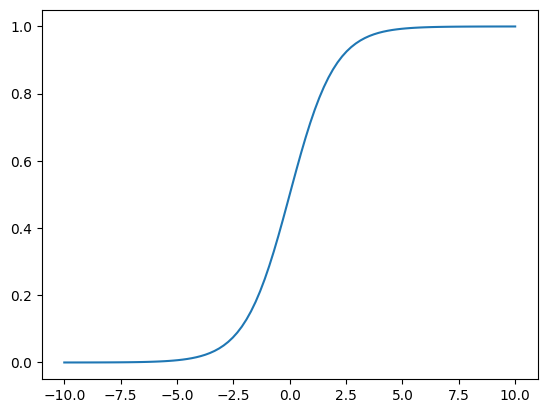

In [35]:
#utiliza la biblioteca Matplotlib para crear un gráfico de la función Sigmoide.
plt.plot(x, sigmoid(x))


Función de pérdida

Error Cuadrático Medio (MSE), una de las métricas de pérdida más comunes en el aprendizaje automático. Esta función también puede calcular la derivada del MSE, lo cual es esencial para el entrenamiento de redes neuronales.

In [36]:
def mse(y,y_hat,derivate=False): #Un argumento opcional que, si es True, indica que se debe calcular la derivada del MSE. Por defecto es False.
    if derivate:
        return (y_hat - y)
    #la función devuelve la diferencia entre las predicciones y los valores reales,  le indica a la red cómo ajustar sus pesos para reducir el error.
    else:
        return np.mean((y_hat - y)**2)
    #Calcula el promedio de todos los errores al cuadrado. Este es el valor final del MSE, una única cifra que resume qué tan bien, en promedio, el modelo predice los valores. 

In [37]:
a  = np.array([[2,3], #sta línea crea un arreglo de NumPy llamado a. Es una matriz de 3 filas y 2 columnas
[2,3],
[2,3]])

a.shape #Este atributo devuelve la forma o las dimensiones del arreglo 

b = np.array([[1,6,5,2],
              [1,2,7,0]]) #una matriz de 2 filas y 4 columnas,

b.shape #Este atributo devuelve la forma del arreglo b

np.matmul(a,b) #el número de columnas de la primera matriz debe ser igual al número de filas de la segunda matriz.

a@b  #El símbolo @ es el operador de multiplicación de matrices.

array([[ 5, 18, 31,  4],
       [ 5, 18, 31,  4],
       [ 5, 18, 31,  4]])

Función de entrenamiento

Este código define una función de entrenamiento (train) para una red neuronal de 3 capas. La función implementa tanto el pase hacia adelante (forward propagation) como la retropropagación (backpropagation) para ajustar los parámetros de la red.

In [38]:
def train(X_data,lr,params,training=True):
## Forward

    params['A0'] = X_data #se asignan como la activación de la capa 0 (A0), que es la capa de entrada.

    params['Z1'] = np.matmul(params['A0'],params['W1']) + params['b1'] #Se calcula la entrada ponderada para la primera capa oculta (Z1). 
    params['A1'] = relu(params['Z1']) #Se aplica la función de activación ReLU a Z1 para obtener la activación de la capa 1 (A1).

    params['Z2'] = np.matmul(params['A1'],params['W2']) + params['b2']
    params['A2'] = relu(params['Z2'])

    params['Z3'] = np.matmul(params['A2'],params['W3']) + params['b3']
    params['A3'] = sigmoid(params['Z3']) #En la capa de salida, se aplica la función de activación Sigmoide a Z3 para obtener la predicción final (A3)

    output = params['A3']

    if training: # Su objetivo es calcular los gradientes (derivadas de la pérdida) y usarlos para actualizar los pesos y sesgos.

        params['dZ3'] =  mse(Y,output,True) * sigmoid(params['A3'],True) # Se calcula el gradiente del error en la capa de salida (dZ3). 
        params['dW3'] = np.matmul(params['A2'].T,params['dZ3']) #Se calcula el gradiente de los pesos de la capa 3 (dW3).

        params['dZ2'] = np.matmul(params['dZ3'],params['W3'].T) * relu(params['A2'],True)
        params['dW2'] = np.matmul(params['A1'].T,params['dZ2'])

        params['dZ1'] = np.matmul(params['dZ2'],params['W2'].T) * relu(params['A1'],True)
        params['dW1'] = np.matmul(params['A0'].T,params['dZ1'])

     #Finalmente, los parámetros se actualizan en la dirección opuesta a su gradiente

        params['W3'] = params['W3'] - params['dW3'] * lr
        params['b3'] = params['b3'] - (np.mean(params['dZ3'],axis=0, keepdims=True)) * lr

        params['W2'] = params['W2'] - params['dW2'] * lr
        params['b2'] = params['b2'] - (np.mean(params['dZ2'],axis=0, keepdims=True)) * lr

        params['W1'] = params['W1'] -params['dW1'] * lr
        params['b1'] = params['b1'] - (np.mean(params['dZ1'],axis=0, keepdims=True)) * lr

    return output #La función devuelve la predicción de la red, que es útil para evaluar el rendimiento antes o después del entrenamiento.

Entrenando la red

Este código configura y entrena una red neuronal profunda. este código ejecuta un proceso de descenso de gradiente a gran escala para entrenar la red neuronal, optimizando sus parámetros para minimizar el error de predicción.

In [41]:
layer_dims =[2, 4, 8, 1]
params = initialize_parameters_deep(layer_dims)
errors = []
for _ in range(50000):
    output = train(X,0.001,params)
    if _ % 25 == 0:
        print(mse(Y,output))
        errors.append(mse(Y,output))

#Define la arquitectura de la red neuronal. Es una lista que especifica el número de neuronas en cada capa.
#Llama a la función que inicializa los pesos (W) y sesgos (b) de la red con valores aleatorios
#Estos parámetros se almacenan en el diccionario params y son el punto de partida para el entrenamiento.
#Crea una lista vacía para almacenar el error (MSE) de la red en ciertos intervalos durante el entrenamiento.
#Cada repetición es una "época" de entrenamiento, donde la red procesa los datos, calcula el error y ajusta sus parámetros.
#Llama a la función train, la cual ejecuta un ciclo completo de entrenamiento:
#La tasa de aprendizaje (learning rate). Este valor determina qué tan grandes son los ajustes a los parámetros en cada iteración.
#Esta es una condición para mostrar el progreso cada 25 interaccion
#Esto nos permite ver cómo el error disminuye a medida que la red aprende. 
# #El valor del MSE se añade a la lista errors para poder visualizar la curva de error más tarde.

0.2658795550728605
0.23574961853177268
0.23062854276840392
0.22341514716054345
0.21273063571540143
0.20139892417710864
0.18927317164686497
0.17626859012713658
0.16239022871495626
0.14860029162847302
0.13536375207658904
0.12291462440755142
0.11102790487227852
0.09981158775122972
0.09021797894388027
0.08212556390111726
0.07542976742495767
0.06952575050787257
0.06452622924407089
0.06022434457545835
0.05662792304724656
0.05357779470324983
0.05100864714774129
0.048813392184512486
0.04682996442968876
0.045061232514318664
0.04346084367496688
0.04202383885136035
0.040702735589373984
0.039420686285748366
0.038192978787955606
0.03710858952883164
0.03612602494457592
0.0352230402604835
0.03436061922506231
0.03355892276577124
0.032847952510371765
0.03219910171467468
0.03159392013497429
0.031021314869286654
0.030487530722105468
0.029963315563332937
0.028584753570475685
0.027351412612065352
0.026813130389794628
0.026427480880899322
0.026053343476321187
0.02569223346861702
0.025336703273328962
0.02500

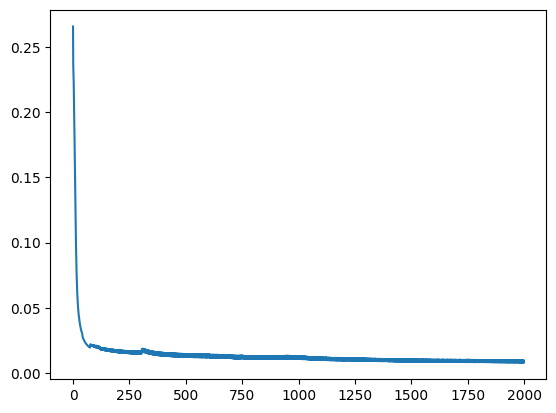

In [42]:
#oma la lista de errores que se ha ido guardando durante el entrenamiento de la red neuronal y la utiliza para crear un gráfico de líneas.
plt.plot(errors)

Probando sobre datos nuevos

El código que proporcionaste evalúa el rendimiento de una red neuronal entrenada en un conjunto de datos de prueba y luego visualiza las predicciones.

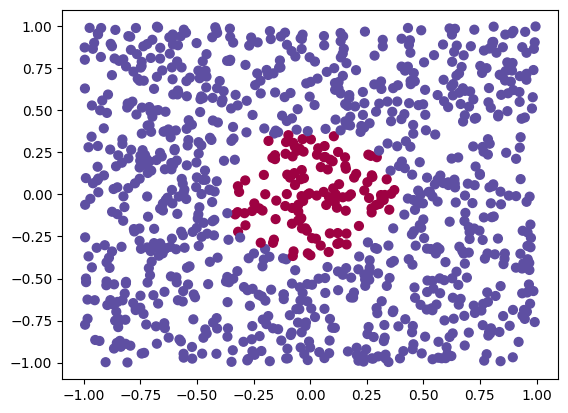

In [43]:
#Esta línea crea un nuevo conjunto de datos sintéticos para probar la red. Genera 1000 puntos de datos, cada uno con 2 características. 

data_test = (np.random.rand(1000, 2) * 2) - 1
y = train(data_test,0.001,params,training=False) #La red simplemente utiliza los parámetros (params) que ya aprendió para hacer inferencias en los nuevos datos de prueba.

y = np.where(y >= 0.5, 1, 0) ##Aquí, las predicciones de probabilidad se convierten en clases binarias (0 o 1)

plt.scatter(data_test[:,0], data_test[:,1], c=y[:,0] ,s=40, cmap=plt.cm.Spectral); # Esta línea finaliza el proceso al visualizar el resultado

Malla de visualización

Es un proceso para crear un mapa de colores que muestra qué clase predice la red en cada punto de un plano 2D. El resultado es un mapa de calor que visualiza el límite de decisión de la red.  Las zonas de un color indican que la red predice una clase, y las zonas de otro color indican la otra. La línea divisoria entre los colores es el límite de decisión.

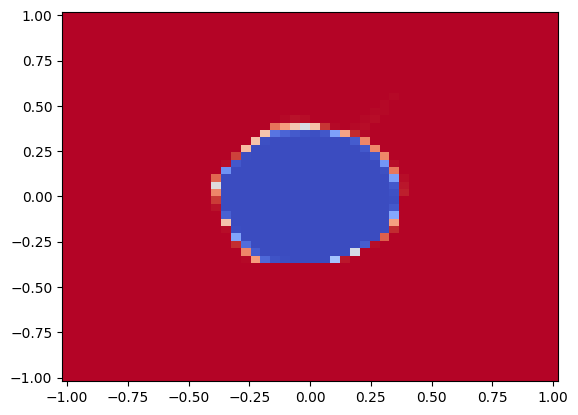

In [45]:
##Estos arreglos representan las coordenadas de una grilla (o cuadrícula) sobre la que la red hará predicciones.
_x0 = np.linspace(-1,1,50)
_x1 = np.linspace(-1,1,50)

#Se crea una matriz de 50x50 llena de ceros. Esta matriz servirá para almacenar las predicciones de la red para cada punto en la grilla.
_y = np.zeros((50,50))

#Cada par (x0, x1) representa un punto único en la grilla 2D.
for i0, x0 in enumerate(_x0):
    for i1, x1 in enumerate(_x1):
        _y[i0,i1] = train(np.array([[x0,x1]]),0.0001,params,training=False).item()

plt.pcolormesh(_x0,_x1,_y,cmap='coolwarm') #pcolormesh es una función de Matplotlib que crea una malla de colores.